# 04 — ECG Signal Forecasting: CNN-LSTM Model (Isolated Testing)
**PTB-XL 12-Lead ECG — Frankfurt University of Applied Sciences · HIS Masters Project**

| | |
|---|---|
| **Task** | **Multivariate Time Series Forecasting** (regression, not classification) |
| **Input** | X_in ∈ ℝ^(12 × 500) — 5 seconds of past ECG across all 12 leads (channel-first) |
| **Target** | y_fore ∈ ℝ^(100 × 12) — next 1 second of ECG signal values in mV |
| **Model** | CNN-LSTM Hybrid — CNN local features + LSTM temporal |
| **Loss** | Huber Loss — smooth, robust to mV outliers |
| **Metrics** | MAE · RMSE · MAPE per lead and macro-averaged |
| **Data** | Loaded from `data/processed/` (output of `02_preprocessing_forecasting.ipynb`) |

## Purpose
This notebook isolates the **CNN-LSTM** model for debugging and testing.
By training only one model in isolation, we can identify specific issues:
- Data loading and shape verification
- Model architecture correctness
- Training stability and convergence
- Gradient flow and loss behavior

## CNN-LSTM Architecture
```
Input  (B, 12, 500)          channel-first
   ↓  Conv1d blocks: 500 → 250 → 125 → 62 timesteps
   ↓  permute → (B, 62, 128)
   ↓  Bidirectional LSTM hidden=128 × 2 layers
   ↓  Attention pooling → (B, 256)
   ↓  Linear(256→100×12)
Output (B, 100, 12)  — continuous mV forecast
```

## Cell 1 — Install & Import

In [1]:
# ============================================================
# CELL 1: INSTALL & IMPORT
# ============================================================
!pip install torch torchvision scikit-learn matplotlib numpy tqdm --quiet

import os, pickle, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("\n✅ All imports ready")

PyTorch  : 2.11.0
Device   : cpu

✅ All imports ready


## Cell 2 — Load Processed Data

In [2]:
# ============================================================
# CELL 2: LOAD PROCESSED DATA FROM 02_PREPROCESSING
# ============================================================

SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures', 'cnn_lstm')
CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))  # (N, 500, 12)
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))  # (N, 100, 12) ← signal, not labels
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']      # 500
HORIZON    = cfg['horizon']        # 100
N_LEADS    = cfg['n_leads']        # 12

print("=" * 60)
print("  DATA LOADED")
print("=" * 60)
print(f"  Task        : {cfg['task']}  |  target: {cfg['target_type']}")
print(f"  X_train     : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val       : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test      : {X_test.shape}    y_test  : {y_test.shape}")
print(f"  Input window: {INPUT_LEN} samples = {INPUT_LEN/FS:.0f}s")
print(f"  Horizon     : {HORIZON} samples = {HORIZON/FS:.0f}s")
print(f"  Device      : {DEVICE}")
print()

# ── Assert this is forecasting data, not classification ───────
assert y_train.ndim == 3, "y_train must be (N, HORIZON, 12) — 3D signal array"
assert y_train.shape[1] == HORIZON
assert y_train.shape[2] == N_LEADS
assert y_train.dtype == np.float32

print("✅ Data verified: y_train is continuous signal (not class labels)")
print(f"   y_train value range: [{y_train.min():.3f}, {y_train.max():.3f}] mV")

  DATA LOADED
  Task        : forecasting  |  target: continuous_signal_mv
  X_train     : (250896, 500, 12)   y_train : (250896, 100, 12)
  X_val       : (31360, 500, 12)    y_val   : (31360, 100, 12)
  X_test      : (17584, 500, 12)    y_test  : (17584, 100, 12)
  Input window: 500 samples = 5s
  Horizon     : 100 samples = 1s
  Device      : cpu

✅ Data verified: y_train is continuous signal (not class labels)
   y_train value range: [-3.000, 3.000] mV


## Cell 3 — PyTorch Dataset & DataLoaders

In [3]:
# ============================================================
# CELL 3: PYTORCH DATASET & DATALOADERS FOR CNN-LSTM
# ============================================================

class ECGForecastDataset(Dataset):
    """
    PyTorch Dataset for PTB-XL multivariate ECG forecasting.

    x → past signal window   (INPUT_LEN, 12) or (12, INPUT_LEN)
    y → future signal window (HORIZON, 12)     ← continuous mV regression target
    """
    def __init__(self, X, y, channel_first=False):
        self.X            = torch.from_numpy(X)   # float32
        self.y            = torch.from_numpy(y)   # float32
        self.channel_first = channel_first

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]    # (500, 12)
        y = self.y[idx]    # (100, 12)
        if self.channel_first:
            x = x.permute(1, 0)   # → (12, 500) for CNN
        return x, y


def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 channel_first=False, batch_train=64, batch_eval=128):
    # num_workers=0 is required in Jupyter notebooks on macOS/Windows.
    # PyTorch multiprocessing (spawn) cannot pickle classes defined in
    # notebook cells. num_workers=0 runs data loading in the main process.
    # On a Linux server or Colab, you can safely set num_workers=4.
    n_cpu = 0
    pin   = (DEVICE.type == 'cuda') and (n_cpu > 0)
    kw    = dict(num_workers=n_cpu, pin_memory=pin)

    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, channel_first),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te

# Channel-first loaders → (B, 12, 500)  for CNN-LSTM
cnn_tr, cnn_vl, cnn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test, channel_first=True)

xb, yb = next(iter(cnn_tr))
print(f"CNN-LSTM batch: x={xb.shape}  y={yb.shape}  dtype={xb.dtype}")
print(f"Train batches: {len(cnn_tr)} | Val: {len(cnn_vl)} | Test: {len(cnn_te)}")
print("\n✅ DataLoaders ready — channel-first format for CNN")

CNN-LSTM batch: x=torch.Size([64, 12, 500])  y=torch.Size([64, 100, 12])  dtype=torch.float32
Train batches: 3920 | Val: 245 | Test: 138

✅ DataLoaders ready — channel-first format for CNN


## Cell 4 — CNN-LSTM Model Architecture

```
Input  (B, 12, 500)          channel-first
   ↓  Conv1d blocks: 500 → 250 → 125 → 62 timesteps
   ↓  permute → (B, 62, 128)
   ↓  Bidirectional LSTM hidden=128 × 2 layers
   ↓  Attention pooling → (B, 256)
   ↓  Linear(256→100×12)
Output (B, 100, 12)  — continuous mV forecast
```

The CNN extracts local morphological features (QRS shape, P-wave onset, T-wave morphology) at multiple temporal scales via learned 1-D filters, compressing 500 → 62 timesteps. This reduces the sequence length fed to the LSTM by 8×, improving gradient flow and training efficiency while preserving the most discriminative signal features.

In [4]:
# ============================================================
# CELL 4: CNN-LSTM MODEL ARCHITECTURE
# ============================================================

class ConvBlock(nn.Module):
    """Conv1d → BatchNorm1d → GELU → optional MaxPool1d."""
    def __init__(self, in_ch, out_ch, k, pool=True):
        super().__init__()
        ops = [
            nn.Conv1d(in_ch, out_ch, kernel_size=k,
                      padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        ]
        if pool:
            ops.append(nn.MaxPool1d(2))
        self.net = nn.Sequential(*ops)

    def forward(self, x):
        return self.net(x)


class CNNLSTMForecaster(nn.Module):
    """
    CNN-LSTM hybrid for multivariate ECG forecasting.

    The CNN extracts local morphological features (QRS shape,
    P-wave onset, T-wave morphology) at multiple temporal scales
    via learned 1-D filters, compressing 500 → 62 timesteps.
    This reduces the sequence length fed to the LSTM by 8×,
    improving gradient flow and training efficiency while
    preserving the most discriminative signal features.

    Input  : (B, 12, 500)  channel-first
    Output : (B, 100, 12)  continuous mV forecast
    """

    def __init__(self, n_leads=12, horizon=100, dropout=0.2,
                 lstm_hidden=128, bidirectional=True):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads
        self.D       = 2 if bidirectional else 1

        # CNN: 500 → 250 → 125 → 62
        self.cnn = nn.Sequential(
            ConvBlock(n_leads, 32,  k=7, pool=True),
            ConvBlock(32,      64,  k=5, pool=True),
            ConvBlock(64,      128, k=3, pool=True),
            ConvBlock(128,     128, k=3, pool=False),
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size    = 128,
            hidden_size   = lstm_hidden,
            num_layers    = 2,
            batch_first   = True,
            dropout       = dropout,
            bidirectional = bidirectional,
        )

        # Temporal attention
        self.attn = nn.Sequential(
            nn.Linear(lstm_hidden * self.D, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.LayerNorm(lstm_hidden * self.D),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * self.D, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, horizon * n_leads),
        )

    def forward(self, x):
        f   = self.cnn(x).permute(0, 2, 1)              # (B, 62, 128)
        enc, _ = self.lstm(f)                            # (B, 62, hidden*D)
        w   = torch.softmax(self.attn(enc), dim=1)       # (B, 62, 1)
        ctx = (w * enc).sum(dim=1)                       # (B, hidden*D)
        out = self.decoder(ctx)
        return out.view(-1, self.horizon, self.n_leads)  # (B, 100, 12)


print("✅ CNN-LSTM model class defined")

✅ CNN-LSTM model class defined


## Cell 5 — Instantiate CNN-LSTM Model

In [5]:
# ============================================================
# CELL 5: INSTANTIATE CNN-LSTM MODEL
# ============================================================

model = CNNLSTMForecaster(
    n_leads=N_LEADS, horizon=HORIZON, dropout=0.2,
    lstm_hidden=128, bidirectional=True
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    test_output = model(test_input)
    print(f"✅ Forward pass test:")
    print(f"   Input:  {test_input.shape}")
    print(f"   Output: {test_output.shape}")

print(f"\n  Total parameters: {n_params:,}")
print(f"  Model device: {DEVICE}")
print(f"\n✅ CNN-LSTM model ready for training")

✅ Forward pass test:
   Input:  torch.Size([4, 12, 500])
   Output: torch.Size([4, 100, 12])

  Total parameters: 1,138,033
  Model device: cpu

✅ CNN-LSTM model ready for training


## Cell 6 — Training Engine

In [6]:
# ============================================================
# CELL 6: TRAINING ENGINE (Clean Progress Bars)
# ============================================================

from tqdm.auto import tqdm
import time

def train_epoch(model, loader, criterion, optimizer, device):
    """Train one epoch."""
    model.train()
    total_loss = 0.0
    batch_count = 0
    
    # Progress bar for batches
    pbar = tqdm(loader, desc='Training batches', leave=False, ncols=90)
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        
        pred = model(xb)
        loss = criterion(pred, yb)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item() * len(xb)
        batch_count += len(xb)
        
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return total_loss / batch_count


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0.0
    batch_count = 0
    preds = []
    targets = []
    
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        
        total_loss += loss.item() * len(xb)
        batch_count += len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    
    avg_loss = total_loss / batch_count
    preds_all = np.concatenate(preds, axis=0)
    targets_all = np.concatenate(targets, axis=0)
    
    return avg_loss, preds_all, targets_all


def train_cnn_lstm(model, tr_loader, vl_loader, n_epochs=60, lr=3e-4, patience=20):
    """Train CNN-LSTM model with clean progress bars."""
    criterion = nn.HuberLoss(delta=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr/20)

    best_val = float('inf')
    no_improve = 0
    ckpt_path = os.path.join(CKPT_DIR, 'CNN-LSTM_final.pt')
    history = {'train_loss': [], 'val_loss': []}

    print(f"\n{'─'*70}")
    print(f"  Training CNN-LSTM Model")
    print(f"{'─'*70}")
    
    # Main epoch progress bar - CLEAN VERSION
    epoch_pbar = tqdm(range(1, n_epochs + 1), 
                      desc='Epoch Progress', 
                      unit='epoch',
                      ncols=90)
    
    start_time = time.time()
    
    for ep in epoch_pbar:
        tr_loss = train_epoch(model, tr_loader, criterion, optimizer, DEVICE)
        vl_loss, _, _ = eval_epoch(model, vl_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            status = '★ BEST'
        else:
            no_improve += 1
            status = ''

        lr_now = optimizer.param_groups[0]['lr']
        
        # Update progress bar
        epoch_pbar.set_description(f'Epoch {ep:2d}/{n_epochs}')
        epoch_pbar.set_postfix({
            'train': f'{tr_loss:.5f}',
            'val': f'{vl_loss:.5f}',
            'best': f'{best_val:.5f}'
        })
        
        # Print detailed line every 5 epochs or on improvement
        if ep % 5 == 0 or is_best:
            tqdm.write(f"  {ep:>3d} | Train: {tr_loss:8.5f} | Val: {vl_loss:8.5f} | LR: {lr_now:.2e} {status}")

        if no_improve >= patience:
            tqdm.write(f"\n  ⏹️ Early stopping at epoch {ep}")
            break

    elapsed = time.time() - start_time
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    
    print(f"\n{'─'*70}")
    print(f"  Best validation loss: {best_val:.6f}")
    print(f"  Training time: {elapsed/60:.1f} minutes")
    print(f"  Checkpoint saved: {ckpt_path}")
    print(f"  ✅ Training complete")
    print(f"{'─'*70}\n")
    
    return history


print("✅ Training functions updated with cleaner progress bars")

✅ Training functions updated with cleaner progress bars


## Cell 7 — Train CNN-LSTM Model

In [7]:
# ============================================================
# CELL 7: TRAIN CNN-LSTM MODEL
# ============================================================

history = train_cnn_lstm(
    model, 
    cnn_tr, 
    cnn_vl, 
    n_epochs=60, 
    lr=3e-4, 
    patience=20
)



──────────────────────────────────────────────────────────────────────
  Training CNN-LSTM Model
──────────────────────────────────────────────────────────────────────


Epoch Progress:   0%|                                           | 0/60 [00:00<?, ?epoch/s]

Training batches:   0%|                                          | 0/3920 [00:00<?, ?it/s]

    1 | Train:  0.27825 | Val:  0.27635 | LR: 3.00e-04 ★ BEST


Training batches:   0%|                                          | 0/3920 [00:00<?, ?it/s]

...

Training batches:   0%|                                          | 0/3920 [00:00<?, ?it/s]

Training batches:   0%|                                          | 0/3920 [00:00<?, ?it/s]

Training batches:   0%|                                          | 0/3920 [00:00<?, ?it/s]

Training batches:   0%|                                          | 0/3920 [00:00<?, ?it/s]


  ⏹️ Early stopping at epoch 54

──────────────────────────────────────────────────────────────────────
  Best validation loss: 0.167200
  Training time: 992.8 minutes
  Checkpoint saved: ../reports/checkpoints/CNN-LSTM_final.pt
  ✅ Training complete
──────────────────────────────────────────────────────────────────────



## Cell 8 — Plot Training History

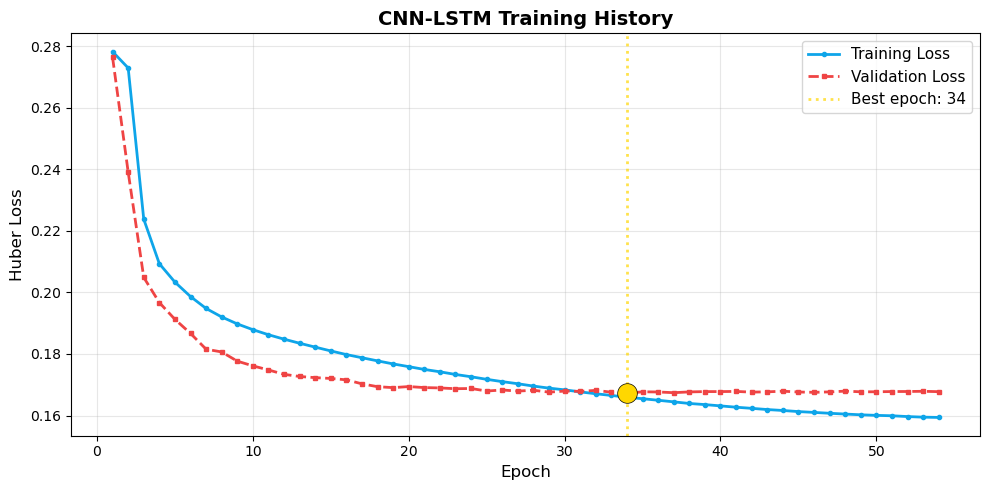

✅ Saved → ../reports/figures/cnn_lstm/training_history.png


In [8]:
# ============================================================
# CELL 8: PLOT TRAINING HISTORY
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ep = range(1, len(history['train_loss']) + 1)
ax.plot(ep, history['train_loss'], color='#0ea5e9', lw=2, label='Training Loss', marker='o', markersize=3)
ax.plot(ep, history['val_loss'], color='#ef4444', lw=2, label='Validation Loss', marker='s', markersize=3, linestyle='--')

best_ep = int(np.argmin(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
ax.axvline(best_ep, color='gold', ls=':', lw=2, alpha=0.7, label=f'Best epoch: {best_ep}')
ax.scatter([best_ep], [best_val_loss], color='gold', s=200, marker='o', zorder=5, edgecolors='black', linewidth=0.5)

ax.set_title('CNN-LSTM Training History', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Huber Loss', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved → {os.path.join(FIG_DIR, 'training_history.png')}")

## Cell 9 — Evaluate on Test Set

In [9]:
# ============================================================
# CELL 9: EVALUATE ON TEST SET
# ============================================================

criterion = nn.HuberLoss(delta=0.5)
test_loss, test_preds, test_targets = eval_epoch(model, cnn_te, criterion, DEVICE)

print(f"\n{'='*60}")
print(f"  TEST SET EVALUATION")
print(f"{'='*60}")
print(f"  Test Loss (Huber): {test_loss:.6f}")
print(f"  Test predictions shape: {test_preds.shape}")
print(f"  Test targets shape:     {test_targets.shape}")

# Compute per-lead metrics
mae_per_lead = []
rmse_per_lead = []

for lead_idx in range(N_LEADS):
    pred_lead = test_preds[:, :, lead_idx].flatten()
    target_lead = test_targets[:, :, lead_idx].flatten()
    
    mae = mean_absolute_error(target_lead, pred_lead)
    rmse = np.sqrt(mean_squared_error(target_lead, pred_lead))
    
    mae_per_lead.append(mae)
    rmse_per_lead.append(rmse)

mae_macro = np.mean(mae_per_lead)
rmse_macro = np.mean(rmse_per_lead)

print(f"\n  Per-Lead MAE (mV):")
for i, lead in enumerate(LEAD_NAMES):
    print(f"    {lead:>3s}: {mae_per_lead[i]:.6f}")
print(f"    MACRO: {mae_macro:.6f}")

print(f"\n  Per-Lead RMSE (mV):")
for i, lead in enumerate(LEAD_NAMES):
    print(f"    {lead:>3s}: {rmse_per_lead[i]:.6f}")
print(f"    MACRO: {rmse_macro:.6f}")

print(f"\n✅ Evaluation complete")


  TEST SET EVALUATION
  Test Loss (Huber): 0.168521
  Test predictions shape: (17584, 100, 12)
  Test targets shape:     (17584, 100, 12)

  Per-Lead MAE (mV):
      I: 0.519370
     II: 0.477820
    III: 0.543982
    aVR: 0.478746
    aVL: 0.556618
    aVF: 0.506970
     V1: 0.556798
     V2: 0.477261
     V3: 0.478425
     V4: 0.482804
     V5: 0.495893
     V6: 0.516781
    MACRO: 0.507622

  Per-Lead RMSE (mV):
      I: 0.829736
     II: 0.792535
    III: 0.873680
    aVR: 0.782897
    aVL: 0.878100
    aVF: 0.830478
     V1: 0.902680
     V2: 0.843149
     V3: 0.857414
     V4: 0.860822
     V5: 0.861728
     V6: 0.861589
    MACRO: 0.847901

✅ Evaluation complete


## Cell 10 — Plot Per-Lead RMSE

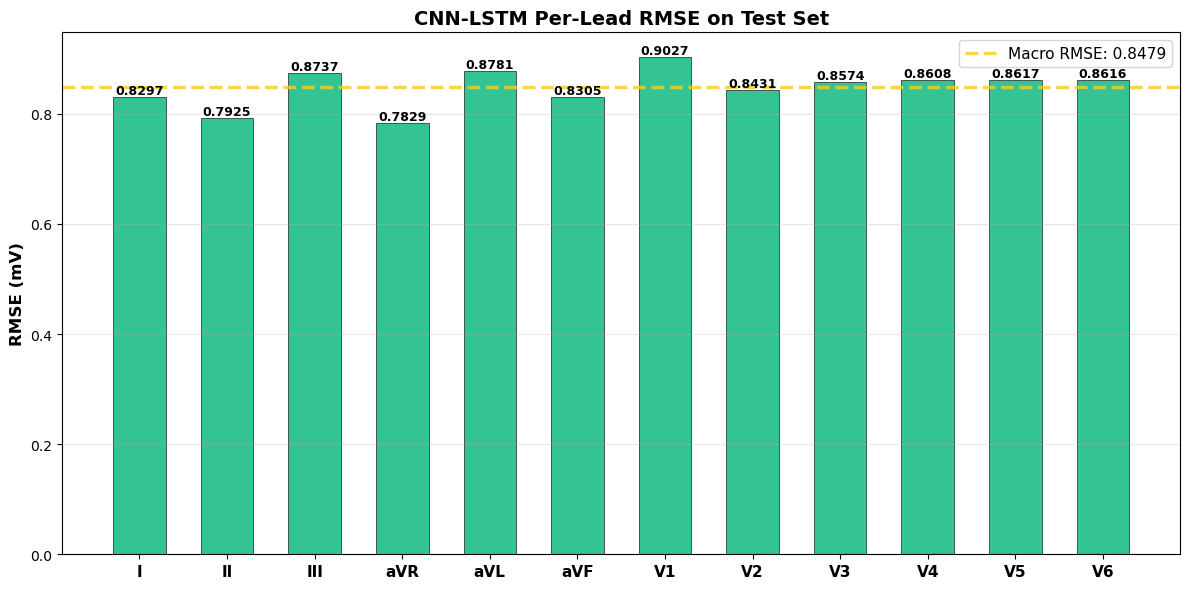

✅ Saved → ../reports/figures/cnn_lstm/per_lead_rmse.png


In [10]:
# ============================================================
# CELL 10: PLOT PER-LEAD RMSE
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x_pos = np.arange(len(LEAD_NAMES))
bars = ax.bar(x_pos, rmse_per_lead, width=0.6, color='#10b981', alpha=0.85, edgecolor='black', linewidth=0.5)

# Add macro line
ax.axhline(rmse_macro, color='#facc15', ls='--', lw=2.5, label=f'Macro RMSE: {rmse_macro:.4f}', alpha=0.8)

# Add value labels on bars
for bar, val in zip(bars, rmse_per_lead):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(LEAD_NAMES, fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (mV)', fontsize=12, fontweight='bold')
ax.set_title('CNN-LSTM Per-Lead RMSE on Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_lead_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved → {os.path.join(FIG_DIR, 'per_lead_rmse.png')}")

## Cell 11 — Predicted vs Actual Signal Overlay

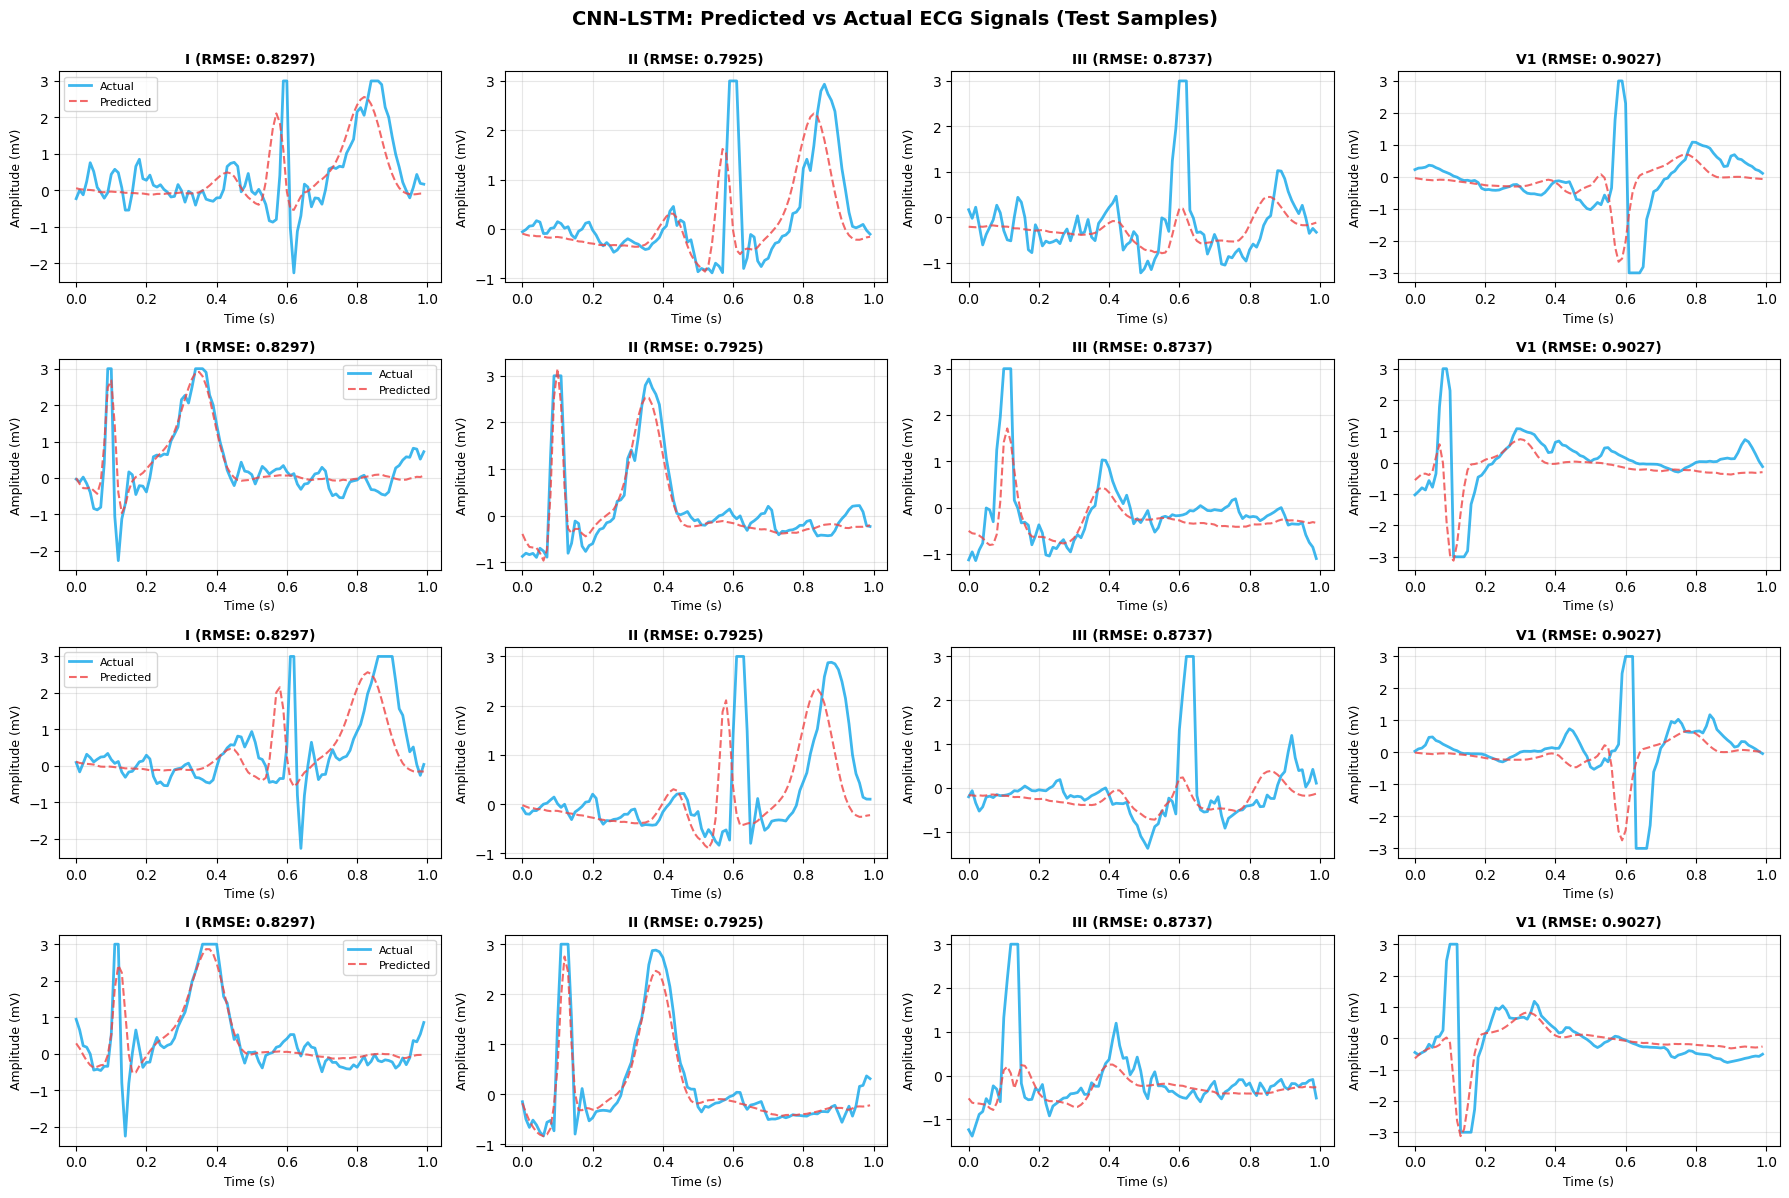

✅ Saved → ../reports/figures/cnn_lstm/predictions_overlay.png


In [11]:
# ============================================================
# CELL 11: PREDICTED VS ACTUAL SIGNAL OVERLAY
# ============================================================

n_samples = 4
fig, axes = plt.subplots(n_samples, 4, figsize=(18, 12))

for sample_idx in range(n_samples):
    pred_sample = test_preds[sample_idx]     # (100, 12)
    target_sample = test_targets[sample_idx] # (100, 12)
    
    # Plot 4 leads: I, II, III, V1
    lead_indices = [0, 1, 2, 6]  # I, II, III, V1
    
    for col, lead_idx in enumerate(lead_indices):
        ax = axes[sample_idx, col]
        t = np.arange(HORIZON) / FS
        
        ax.plot(t, target_sample[:, lead_idx], color='#0ea5e9', lw=2, label='Actual', alpha=0.8)
        ax.plot(t, pred_sample[:, lead_idx], color='#ef4444', lw=1.5, label='Predicted', linestyle='--', alpha=0.8)
        
        rmse_lead = rmse_per_lead[lead_idx]
        ax.set_title(f'{LEAD_NAMES[lead_idx]} (RMSE: {rmse_lead:.4f})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel('Amplitude (mV)', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        if col == 0:
            ax.legend(fontsize=8, loc='best')

fig.suptitle(f'CNN-LSTM: Predicted vs Actual ECG Signals (Test Samples)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved → {os.path.join(FIG_DIR, 'predictions_overlay.png')}")

## Cell 12 — Prediction Error Analysis

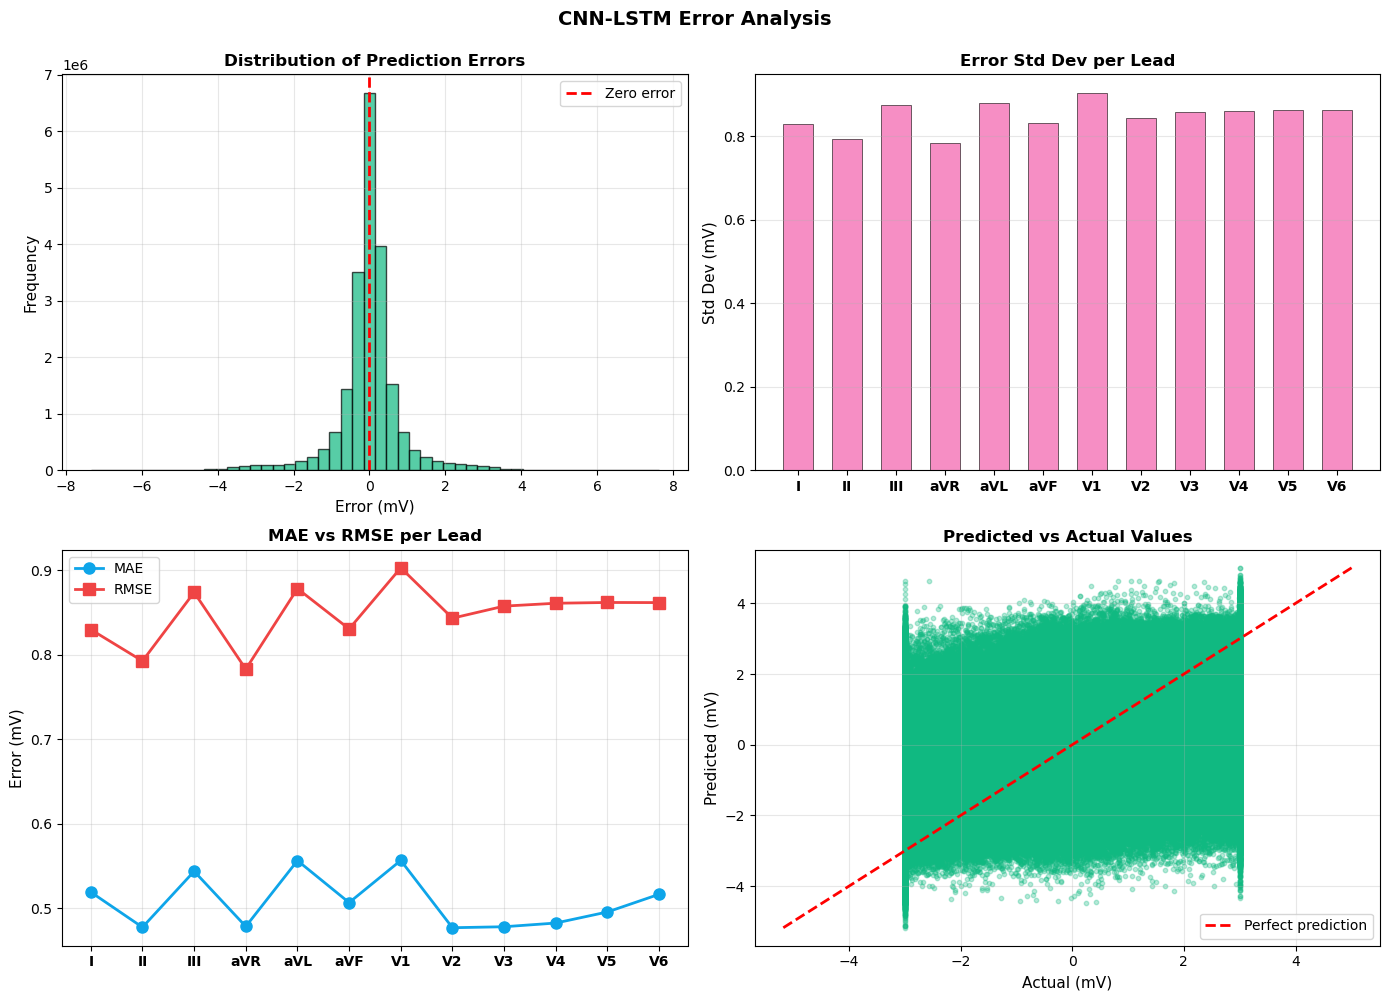

✅ Saved → ../reports/figures/cnn_lstm/error_analysis.png

  Mean error: -0.008311 mV
  Std dev of errors: 0.848507 mV
  Max absolute error: 7.625244 mV


In [12]:
# ============================================================
# CELL 12: PREDICTION ERROR ANALYSIS
# ============================================================

# Compute errors across all samples and leads
errors = test_preds - test_targets  # (n_test, 100, 12)
errors_flat = errors.reshape(-1)    # (n_test * 100 * 12,)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Error histogram
axes[0, 0].hist(errors_flat, bins=50, color='#10b981', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', lw=2, label='Zero error')
axes[0, 0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Error (mV)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Error statistics by lead
error_std_per_lead = []
error_mean_per_lead = []
for lead_idx in range(N_LEADS):
    errors_lead = errors[:, :, lead_idx].flatten()
    error_mean_per_lead.append(np.mean(errors_lead))
    error_std_per_lead.append(np.std(errors_lead))

x_pos = np.arange(len(LEAD_NAMES))
axes[0, 1].bar(x_pos, error_std_per_lead, width=0.6, color='#f472b6', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0, 1].set_title('Error Std Dev per Lead', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Std Dev (mV)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. MAE vs RMSE per lead
axes[1, 0].plot(x_pos, mae_per_lead, marker='o', markersize=8, color='#0ea5e9', lw=2, label='MAE')
axes[1, 0].plot(x_pos, rmse_per_lead, marker='s', markersize=8, color='#ef4444', lw=2, label='RMSE')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[1, 0].set_title('MAE vs RMSE per Lead', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Error (mV)', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Predicted vs Actual scatter plot (sample)
sample_preds = test_preds.flatten()
sample_targets = test_targets.flatten()
axes[1, 1].scatter(sample_targets, sample_preds, alpha=0.3, s=10, color='#10b981')
min_val = min(sample_targets.min(), sample_preds.min())
max_val = max(sample_targets.max(), sample_preds.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[1, 1].set_xlabel('Actual (mV)', fontsize=11)
axes[1, 1].set_ylabel('Predicted (mV)', fontsize=11)
axes[1, 1].set_title('Predicted vs Actual Values', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('CNN-LSTM Error Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved → {os.path.join(FIG_DIR, 'error_analysis.png')}")
print(f"\n  Mean error: {np.mean(errors_flat):.6f} mV")
print(f"  Std dev of errors: {np.std(errors_flat):.6f} mV")
print(f"  Max absolute error: {np.max(np.abs(errors_flat)):.6f} mV")

## Cell 13 — Save Results Summary

In [13]:
# ============================================================
# CELL 13: SAVE RESULTS SUMMARY
# ============================================================

results_summary = {
    'model': 'CNN-LSTM',
    'n_parameters': n_params,
    'test_loss': test_loss,
    'mae_per_lead': mae_per_lead,
    'mae_macro': mae_macro,
    'rmse_per_lead': rmse_per_lead,
    'rmse_macro': rmse_macro,
    'history': history,
    'lead_names': LEAD_NAMES,
    'test_preds': test_preds,
    'test_targets': test_targets,
}

summary_path = os.path.join(CKPT_DIR, 'CNN-LSTM_results_summary.pkl')
with open(summary_path, 'wb') as f:
    pickle.dump(results_summary, f)

print(f"\n{'='*70}")
print(f"  RESULTS SUMMARY")
print(f"{'='*70}")
print(f"  Model: CNN-LSTM")
print(f"  Parameters: {n_params:,}")
print(f"  Test Huber Loss: {test_loss:.6f}")
print(f"  Macro MAE: {mae_macro:.6f} mV")
print(f"  Macro RMSE: {rmse_macro:.6f} mV")
print(f"\n  Results saved → {summary_path}")
print(f"\n✅ All complete!")


  RESULTS SUMMARY
  Model: CNN-LSTM
  Parameters: 1,138,033
  Test Huber Loss: 0.168521
  Macro MAE: 0.507622 mV
  Macro RMSE: 0.847901 mV

  Results saved → ../reports/checkpoints/CNN-LSTM_results_summary.pkl

✅ All complete!
